In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

df = pd.read_csv('cleaned_data.csv', parse_dates=['date'])
print("Data loaded:", df.shape)
df.head()

Data loaded: (27784, 9)


,date,position,song,artist,popularity,album_type,total_tracks,is_explicit,duration_min
0,2024-05-18,1,Like Crazy,Jimin,93,single,6,False,3.54
1,2024-05-18,2,UNFORGIVEN (feat. Nile Rodgers),LE SSERAFIM,87,album,13,False,3.04
2,2024-05-18,3,Spicy,aespa,81,single,6,False,3.28
3,2024-05-18,4,I AM,IVE,89,album,11,False,3.06
4,2024-05-18,5,Queencard,(G)I-DLE,71,single,6,False,2.69


In [3]:
# Why: "Like Crazy" by Jimin and "Like Crazy" by someone else are different songs
# So we combine song + artist into one unique ID
df['song_id'] = df['song'] + " || " + df['artist']

print("Total unique song-artist combinations:", df['song_id'].nunique())

Total unique song-artist combinations: 541


In [4]:
# Sort by song and date
df = df.sort_values(['song_id', 'date']).reset_index(drop=True)

reentry_records = []

for song, group in df.groupby('song_id'):
    group = group.sort_values('date').reset_index(drop=True)
    dates = group['date'].tolist()
    
    # Find gaps — if gap between consecutive appearances > 7 days, it's a re-entry
    reentries = 0
    gaps = []
    for i in range(1, len(dates)):
        gap = (dates[i] - dates[i-1]).days
        if gap > 7:
            reentries += 1
            gaps.append(gap)
    
    reentry_records.append({
        'song_id'        : song,
        'song'           : group['song'].iloc[0],
        'artist'         : group['artist'].iloc[0],
        'total_appearances': len(group),
        'reentry_count'  : reentries,
        'avg_gap_days'   : round(np.mean(gaps), 1) if gaps else 0,
        'max_gap_days'   : max(gaps) if gaps else 0,
        'avg_popularity' : round(group['popularity'].mean(), 2),
        'peak_popularity': group['popularity'].max(),
        'best_position'  : group['position'].min(),
        'album_type'     : group['album_type'].iloc[0],
        'is_explicit'    : group['is_explicit'].iloc[0],
        'duration_min'   : group['duration_min'].iloc[0],
        'total_tracks'   : group['total_tracks'].iloc[0],
    })

reentry_df = pd.DataFrame(reentry_records)
print("Songs that re-entered the chart:")
print(reentry_df[reentry_df['reentry_count'] > 0].shape[0])
print("\nTop 10 Most Re-entered Songs:")
print(reentry_df.sort_values('reentry_count', ascending=False).head(10)[
    ['song','artist','reentry_count','avg_gap_days','peak_popularity']
])

Songs that re-entered the chart:
111

Top 10 Most Re-entered Songs:
                                        song           artist  reentry_count  \
110                                    Ditto         NewJeans              7   
191                                 Hype Boy         NewJeans              6   
314                                      OMG         NewJeans              6   
89                              Cruel Summer     Taylor Swift              5   
122                                      ETA         NewJeans              5   
306                                New Jeans         NewJeans              5   
12                                 A bientot  Lim Young Woong              5   
235  Left and Right (Feat. Jung Kook of BTS)     Charlie Puth              4   
34                                 Attention         NewJeans              4   
80         Closer to You (feat. Major Lazer)        Jung Kook              4   

     avg_gap_days  peak_popularity  
110          1

In [5]:
# Momentum Spike = how sharply popularity jumped when song re-entered
# We calculate: popularity change rate per re-entry window

df = df.sort_values(['song_id', 'date']).reset_index(drop=True)
df['popularity_change'] = df.groupby('song_id')['popularity'].diff()
df['position_change']   = df.groupby('song_id')['position'].diff() * -1  # negative = climbed up

# Momentum Spike Score = popularity jump + rank improvement combined
df['momentum_score'] = (
    df['popularity_change'].clip(lower=0) * 0.6 +
    df['position_change'].clip(lower=0) * 0.4
).round(3)

print("Momentum Score Stats:")
print(df['momentum_score'].describe().round(3))
print("\nTop 10 Highest Momentum Moments:")
print(df.nlargest(10, 'momentum_score')[
    ['date','song','artist','position','popularity','momentum_score']
])

Momentum Score Stats:
count    27243.000
mean         0.587
std          2.352
min          0.000
25%          0.000
50%          0.000
75%          0.600
max         52.600
Name: momentum_score, dtype: float64

Top 10 Highest Momentum Moments:
            date                    song  \
11883 2024-07-29                   K-POP   
364   2024-10-02  3D (feat. Jack Harlow)   
9183  2024-07-30                  HYAENA   
6867  2024-07-30                    FE!N   
15348 2024-07-30                MELTDOWN   
24557 2024-07-30               THANK GOD   
22499 2024-11-05    Standing Next to You   
4712  2025-08-18        Die With A Smile   
15516 2024-07-30              MODERN JAM   
15518 2024-07-30                 MY EYES   

                                      artist  position  popularity  \
11883  Travis Scott & Bad Bunny & The Weeknd        46          91   
364                  Jung Kook & Jack Harlow         2          86   
9183                            Travis Scott        37      

In [6]:
# How many days does a song stay on chart after re-entering?
retention_records = []

for song, group in df.groupby('song_id'):
    group = group.sort_values('date').reset_index(drop=True)
    dates = group['date'].tolist()
    
    for i in range(1, len(dates)):
        gap = (dates[i] - dates[i-1]).days
        if gap > 7:  # this is a re-entry point
            # Count consecutive days after re-entry
            retention = 1
            for j in range(i+1, len(dates)):
                if (dates[j] - dates[j-1]).days <= 7:
                    retention += 1
                else:
                    break
            
            retention_records.append({
                'song_id'        : song,
                'song'           : group['song'].iloc[0],
                'artist'         : group['artist'].iloc[0],
                'reentry_date'   : dates[i],
                'retention_days' : retention,
                'peak_pop_after' : group.iloc[i:i+retention]['popularity'].max(),
                'album_type'     : group['album_type'].iloc[0],
                'is_explicit'    : group['is_explicit'].iloc[0],
            })

retention_df = pd.DataFrame(retention_records)
print(f"Total re-entry events recorded: {len(retention_df)}")
print(f"\nAvg retention after comeback: {retention_df['retention_days'].mean():.1f} days")
print("\nTop 10 Longest Retained Comebacks:")
print(retention_df.sort_values('retention_days', ascending=False).head(10)[
    ['song','artist','reentry_date','retention_days','peak_pop_after']
])

Total re-entry events recorded: 187

Avg retention after comeback: 20.2 days

Top 10 Longest Retained Comebacks:
                       song           artist reentry_date  retention_days  \
2                 A bientot  Lim Young Woong   2024-08-28             215   
113               New Jeans         NewJeans   2025-02-28             141   
55                      ETA         NewJeans   2024-11-23             139   
77                 Hype Boy         NewJeans   2025-04-27             137   
81               I Love You  Lim Young Woong   2024-10-17             129   
127  People Pt.2 (feat. IU)          Agust D   2024-07-02             126   
0           A Psalm of Life  Lim Young Woong   2024-10-16             120   
35             Cruel Summer     Taylor Swift   2024-12-28             119   
96     Love Always Run Away  Lim Young Woong   2024-10-14             117   
99             Lovely Touch  Lim Young Woong   2024-10-22             112   

     peak_pop_after  
2                

In [7]:
# Fandom Intensity = combination of:
# 1. How often they re-enter (re-entry frequency)
# 2. How sharp the popularity spike is (spike sharpness)  
# 3. How fast they recover rank (rank recovery)

song_momentum = df.groupby('song_id')['momentum_score'].agg(['mean','max','sum']).reset_index()
song_momentum.columns = ['song_id','avg_momentum','peak_momentum','total_momentum']

fandom_df = reentry_df.merge(song_momentum, on='song_id', how='left')

# Normalize each component to 0-100 scale
def normalize(series):
    if series.max() == series.min():
        return series * 0
    return ((series - series.min()) / (series.max() - series.min()) * 100).round(2)

fandom_df['reentry_score']  = normalize(fandom_df['reentry_count'])
fandom_df['spike_score']    = normalize(fandom_df['peak_momentum'])
fandom_df['recovery_score'] = normalize(fandom_df['total_appearances'])

# Final Fandom Intensity Proxy Score
fandom_df['fandom_intensity_score'] = (
    fandom_df['reentry_score']  * 0.4 +
    fandom_df['spike_score']    * 0.35 +
    fandom_df['recovery_score'] * 0.25
).round(2)

print("Top 15 Artists by Fandom Intensity Score:")
top_fandom = fandom_df.sort_values('fandom_intensity_score', ascending=False).head(15)
print(top_fandom[['artist','song','reentry_count','fandom_intensity_score']].to_string(index=False))

Top 15 Artists by Fandom Intensity Score:
         artist                                song  reentry_count  fandom_intensity_score
       NewJeans                           New Jeans              5                   73.30
       NewJeans                               Ditto              7                   59.79
       NewJeans                           Super Shy              1                   57.03
          aespa                               Drama              3                   56.37
      Jung Kook   Closer to You (feat. Major Lazer)              4                   55.86
       NewJeans                                 OMG              6                   54.42
       NewJeans                            Hype Boy              6                   52.48
      Jung Kook                Standing Next to You              0                   50.72
            IVE                              Baddie              3                   50.38
       NewJeans                                 

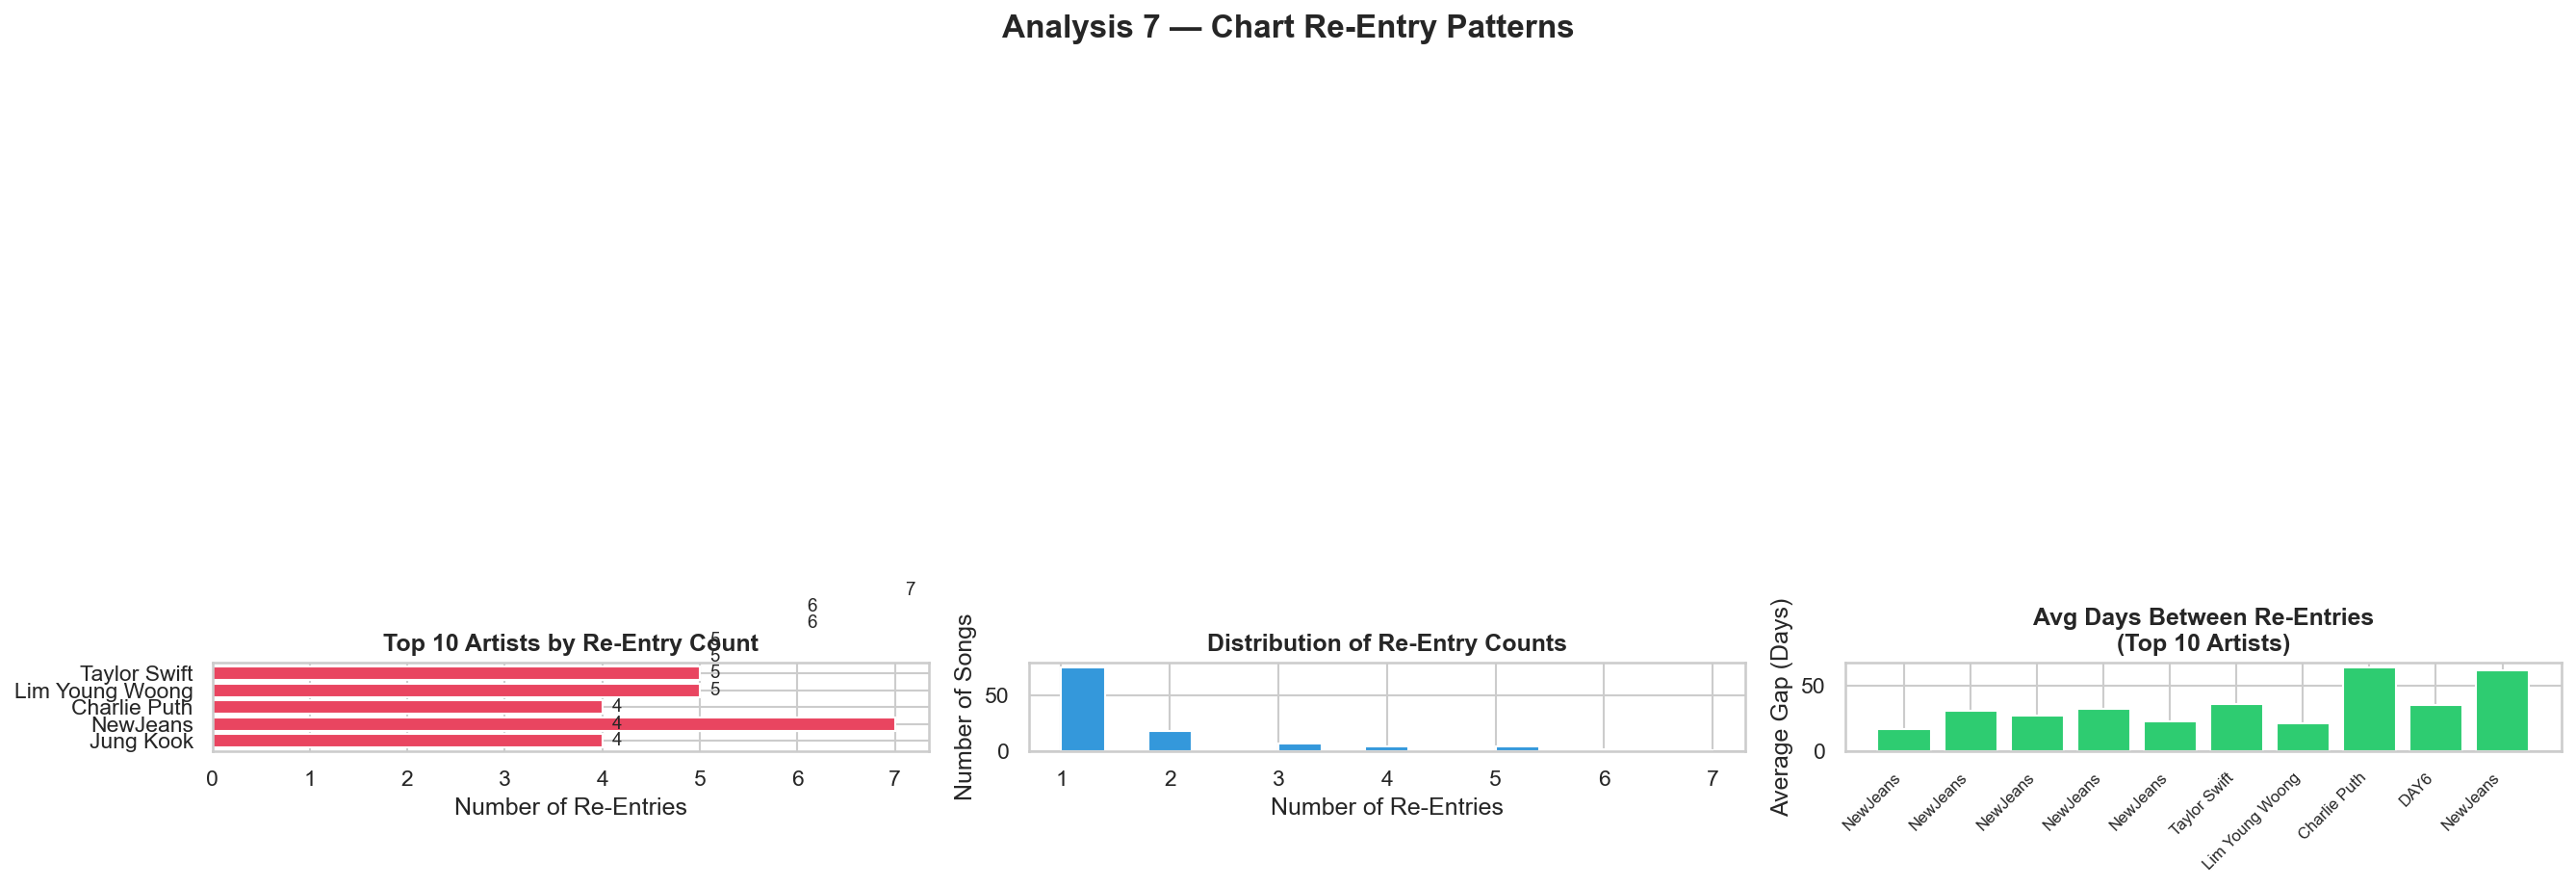

Plot saved!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left — Top 10 most re-entered songs
top_reentry = reentry_df.sort_values('reentry_count', ascending=False).head(10)
axes[0].barh(top_reentry['artist'][::-1], top_reentry['reentry_count'][::-1],
             color='#e94560', edgecolor='white')
axes[0].set_title('Top 10 Artists by Re-Entry Count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Re-Entries')
for i, v in enumerate(top_reentry['reentry_count'][::-1]):
    axes[0].text(v + 0.1, i, str(v), va='center', fontsize=9)

# Middle — Re-entry count distribution
reentry_only = reentry_df[reentry_df['reentry_count'] > 0]['reentry_count']
axes[1].hist(reentry_only, bins=15, color='#3498db', edgecolor='white')
axes[1].set_title('Distribution of Re-Entry Counts', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Re-Entries')
axes[1].set_ylabel('Number of Songs')

# Right — Avg gap days for top re-entered songs
top10 = reentry_df[reentry_df['reentry_count'] > 0].sort_values(
    'reentry_count', ascending=False).head(10)
axes[2].bar(range(len(top10)), top10['avg_gap_days'],
            color='#2ecc71', edgecolor='white')
axes[2].set_xticks(range(len(top10)))
axes[2].set_xticklabels(top10['artist'], rotation=45, ha='right', fontsize=8)
axes[2].set_title('Avg Days Between Re-Entries\n(Top 10 Artists)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Average Gap (Days)')

plt.suptitle('Analysis 7 — Chart Re-Entry Patterns', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/07_reentry_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

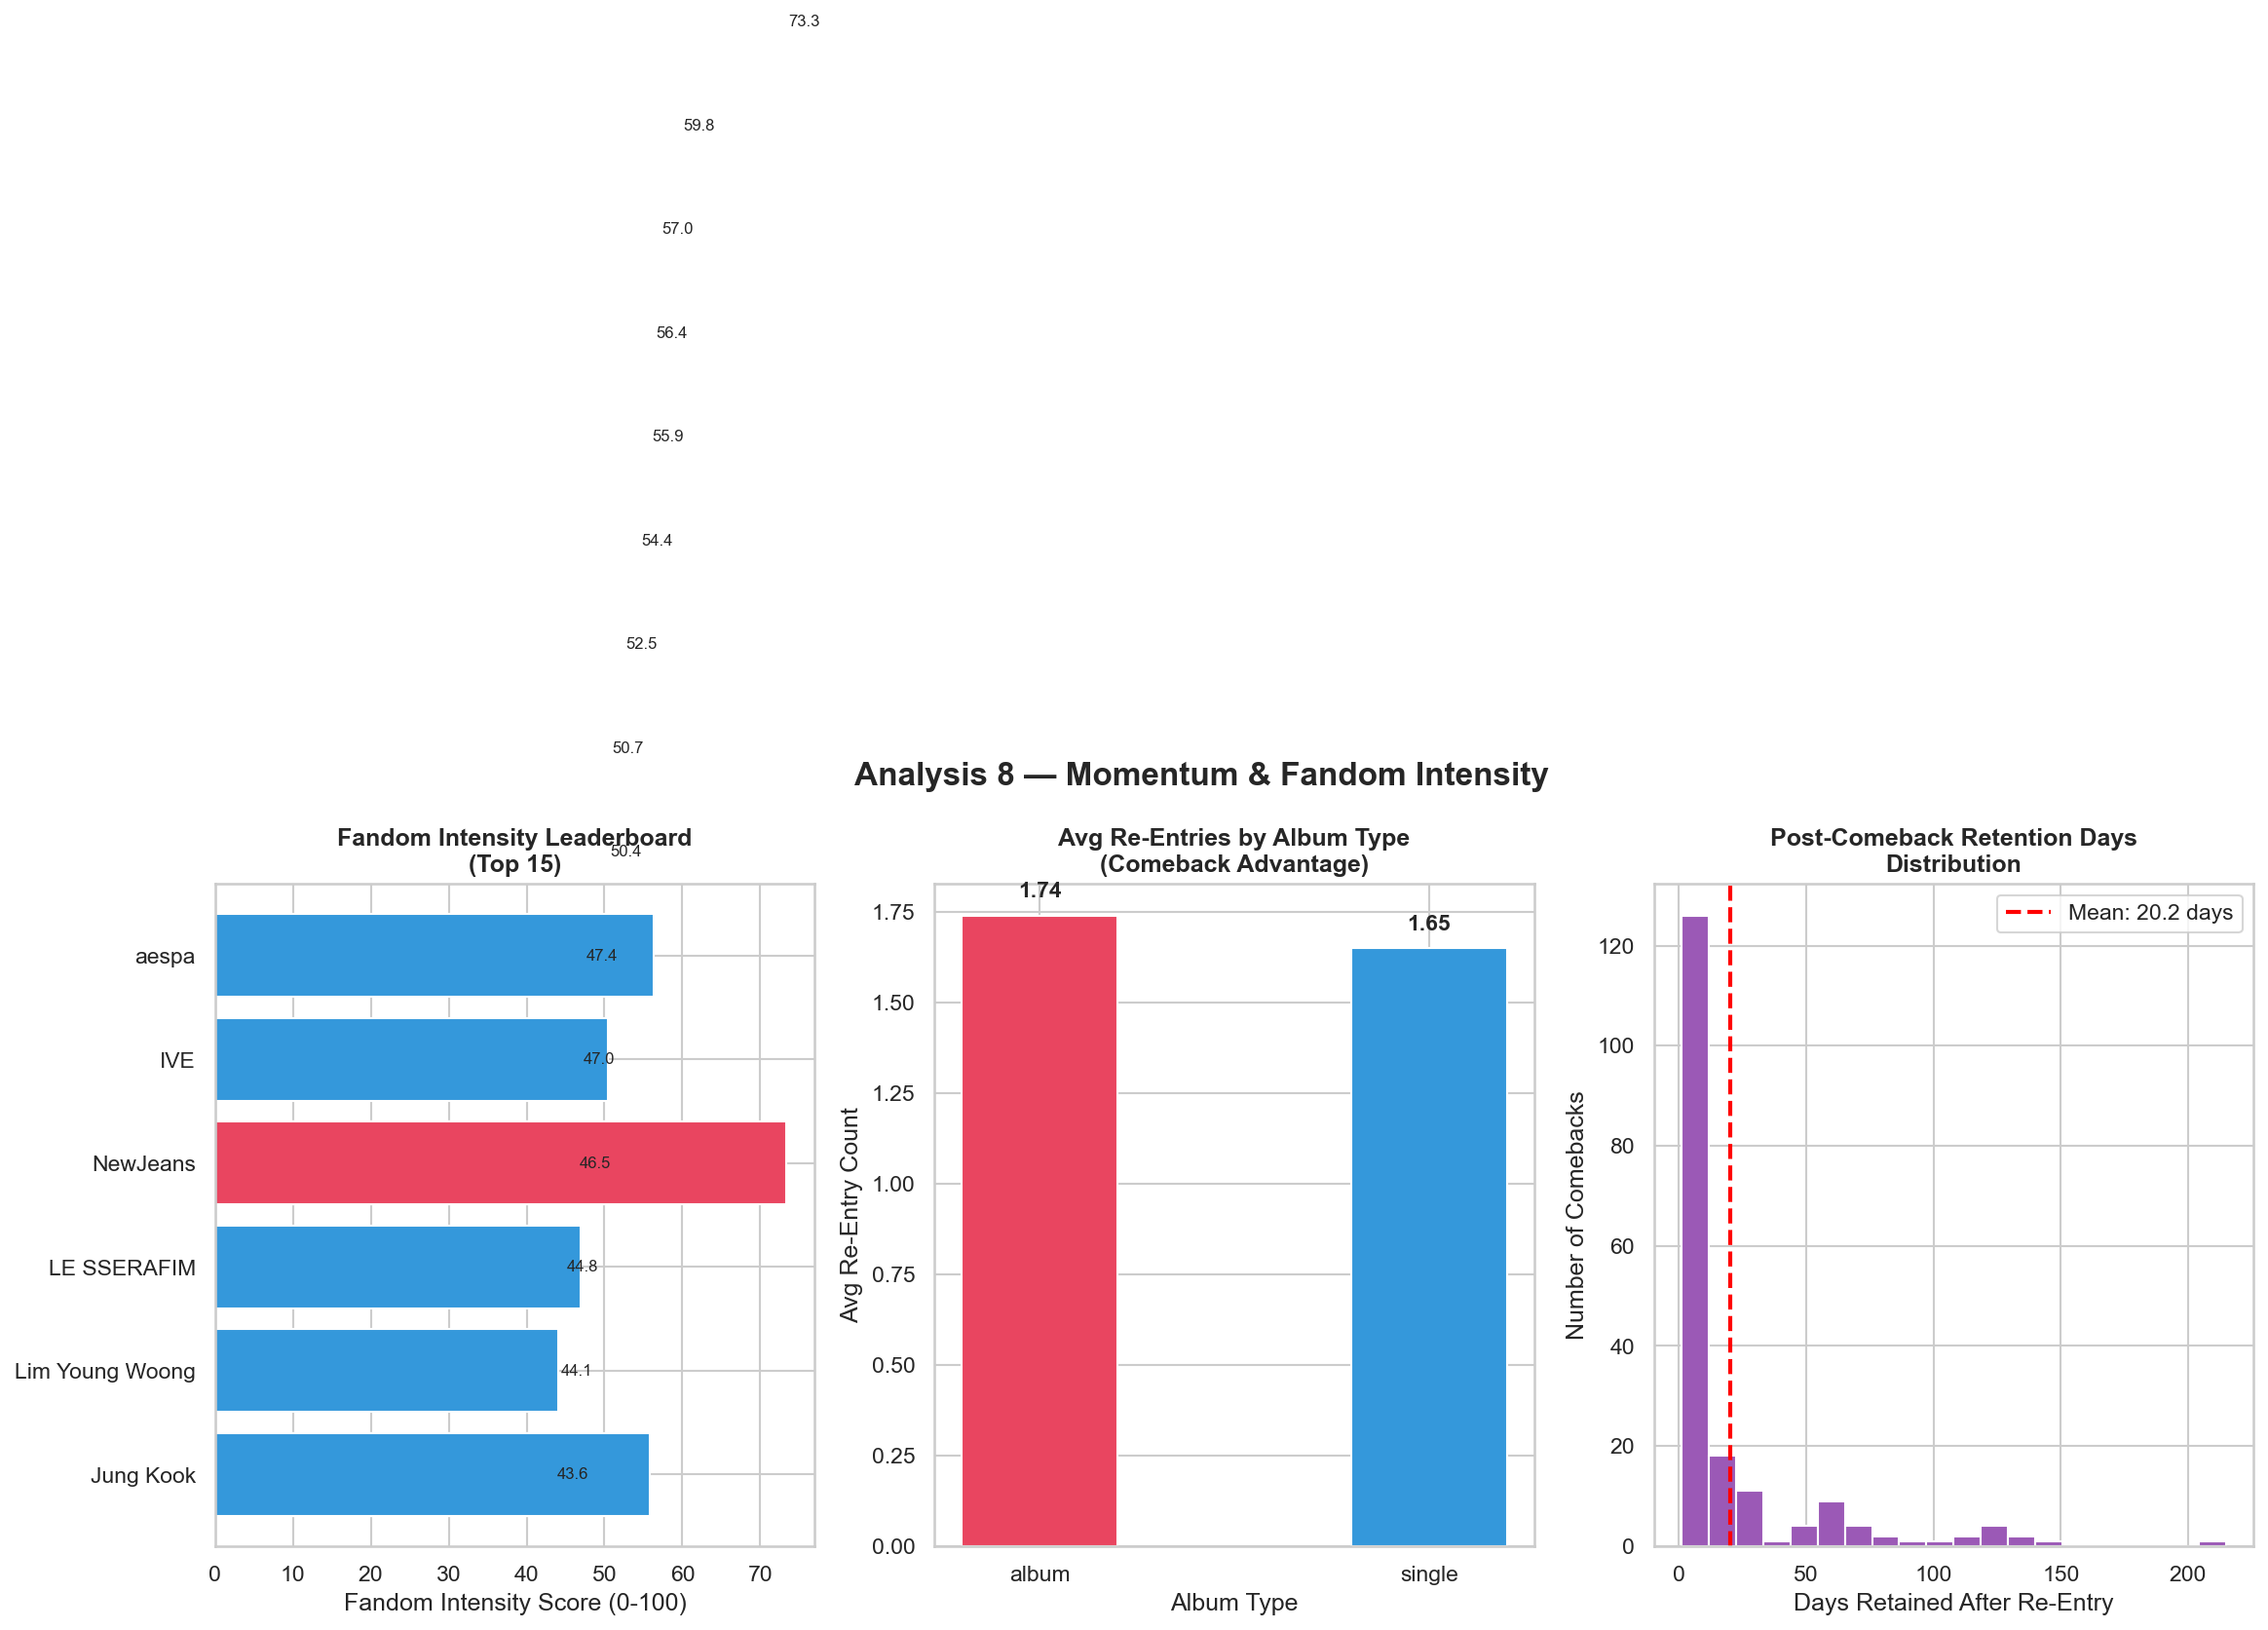

Plot saved!


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left — Fandom Intensity Leaderboard
top15 = fandom_df.sort_values('fandom_intensity_score', ascending=False).head(15)
colors_f = ['#e94560' if i < 3 else '#3498db' for i in range(15)]
axes[0].barh(top15['artist'][::-1], top15['fandom_intensity_score'][::-1],
             color=colors_f[::-1], edgecolor='white')
axes[0].set_title('Fandom Intensity Leaderboard\n(Top 15)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fandom Intensity Score (0-100)')
for i, v in enumerate(top15['fandom_intensity_score'][::-1]):
    axes[0].text(v + 0.3, i, f"{v:.1f}", va='center', fontsize=8)

# Middle — Singles vs Albums comeback strength
comeback_type = reentry_df[reentry_df['reentry_count'] > 0].groupby(
    'album_type')['reentry_count'].mean().round(2)
axes[1].bar(comeback_type.index, comeback_type.values,
            color=['#e94560', '#3498db', '#2ecc71'], edgecolor='white', width=0.4)
axes[1].set_title('Avg Re-Entries by Album Type\n(Comeback Advantage)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Album Type')
axes[1].set_ylabel('Avg Re-Entry Count')
for i, v in enumerate(comeback_type.values):
    axes[1].text(i, v + 0.05, f"{v:.2f}", ha='center', fontsize=11, fontweight='bold')

# Right — Retention days distribution
if len(retention_df) > 0:
    axes[2].hist(retention_df['retention_days'], bins=20,
                 color='#9b59b6', edgecolor='white')
    axes[2].set_title('Post-Comeback Retention Days\nDistribution', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Days Retained After Re-Entry')
    axes[2].set_ylabel('Number of Comebacks')
    axes[2].axvline(retention_df['retention_days'].mean(), color='red',
                    linestyle='--', linewidth=2,
                    label=f"Mean: {retention_df['retention_days'].mean():.1f} days")
    axes[2].legend()

plt.suptitle('Analysis 8 — Momentum & Fandom Intensity', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/08_momentum_fandom.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

In [10]:
# Save these for Streamlit app
reentry_df.to_csv('reentry_analysis.csv', index=False)
fandom_df.to_csv('fandom_scores.csv', index=False)
retention_df.to_csv('retention_analysis.csv', index=False)
df.to_csv('df_with_momentum.csv', index=False)

print("All analysis files saved!")
print("\nFiles created:")
print("  - reentry_analysis.csv")
print("  - fandom_scores.csv")
print("  - retention_analysis.csv")
print("  - df_with_momentum.csv")

All analysis files saved!

Files created:
  - reentry_analysis.csv
  - fandom_scores.csv
  - retention_analysis.csv
  - df_with_momentum.csv
